# 手寫阿拉伯數字辨識 完整版

## 載入套件

In [1]:
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchmetrics
from PIL import Image
from torch import nn, optim
from torch.utils.data import DataLoader
from torchinfo import summary
from torchvision import transforms
from torchvision.datasets import MNIST

## 設定參數

In [2]:
PATH_DATASETS = "data" # 預設路徑
BATCH_SIZE = 1024  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 步驟1：載入 MNIST 手寫阿拉伯數字資料

In [3]:
# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 步驟2：資料探索

In [4]:
train_ds.data.shape, train_ds.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

In [5]:
# 訓練資料前10筆圖片的數字
train_ds.targets[:10]

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

In [6]:
# 顯示第1張圖片內含值
train_ds.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [7]:
# 將非0的數字轉為1，顯示第1張圖片
data = train_ds.data[0].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000001111111111110000',
 '0000000011111111111111110000',
 '0000000111111111111111100000',
 '0000000111111111110000000000',
 '0000000011111110110000000000',
 '0000000001111100000000000000',
 '0000000000011110000000000000',
 '0000000000011110000000000000',
 '0000000000001111110000000000',
 '0000000000000111111000000000',
 '0000000000000011111100000000',
 '0000000000000001111100000000',
 '0000000000000000011110000000',
 '0000000000000011111110000000',
 '0000000000001111111100000000',
 '0000000000111111111000000000',
 '0000000011111111110000000000',
 '0000001111111111000000000000',
 '0000111111111100000000000000',
 '0000111111110000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

In [8]:
# 將非0的數字轉為1，顯示第2張圖片
data = train_ds.data[1].clone()
data[data > 0] = 1
data = data.numpy()

# 將轉換後二維內容顯示出來，隱約可以看出數字為 5
text_image: list[str] = []
for i in range(data.shape[0]):
    text_image.append(''.join(data[i].astype(str)))
text_image

['0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000001111100000000',
 '0000000000000011111100000000',
 '0000000000000111111111000000',
 '0000000000011111111111000000',
 '0000000000011111111111000000',
 '0000000000111111111111000000',
 '0000000001111111110011100000',
 '0000000011111100000011100000',
 '0000000111111100000011100000',
 '0000000111100000000011100000',
 '0000000111000000000011100000',
 '0000001111000000000011100000',
 '0000001111000000001111100000',
 '0000001110000000011111000000',
 '0000001110000000111100000000',
 '0000001110000001111000000000',
 '0000001111111111111000000000',
 '0000001111111111100000000000',
 '0000001111111110000000000000',
 '0000000111111100000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000',
 '0000000000000000000000000000']

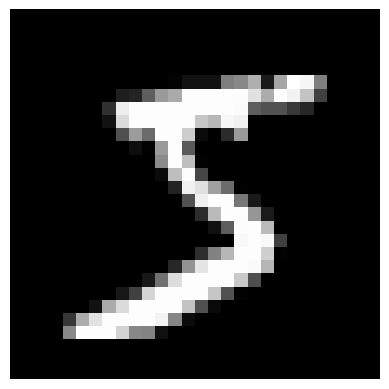

In [9]:
# 顯示第1張圖片圖像
# 第一筆資料
X = train_ds.data[0]

# 繪製點陣圖，cmap='gray':灰階
plt.imshow(X.reshape(28, 28), cmap='gray')

# 隱藏刻度
plt.axis('off')

# 顯示圖形
plt.show()

## 步驟3：特徵工程，此步驟無需進行

In [10]:
# train_ds.data = train_ds.data / 255.0
# test_ds.data = test_ds.data / 255.0

## 步驟4：資料分割，此步驟無需進行，載入MNIST資料時，已經切割好了

## 步驟5：建立模型結構

In [11]:
# 建立模型
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.Dropout(0.2),
    nn.Linear(256, 64),
    nn.Dropout(0.2),
    nn.Linear(64, 10),
).to(device)

## 步驟6：結合訓練資料及模型，進行模型訓練

In [12]:
epochs = 5
lr = 0.1

# 建立 DataLoader
train_loader = DataLoader(train_ds, batch_size=600)

# 設定優化器(optimizer)
# optimizer = optim.Adam(model.parameters(), lr=lr)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

model.train()
loss_list: list[float] = []
correct = y_count = 0
for epoch in range(epochs):
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        # if batch_idx == 0 and epoch == 1: print(data.shape)

        optimizer.zero_grad()
        output: torch.Tensor = model(data)

        pred = output.argmax(dim=1, keepdim=True)
        # 正確筆數
        correct += pred.eq(target.view_as(pred)).sum().item()
        y_count += pred.shape[0]

        # if batch_idx == 0 and epoch == 1: print(output.shape, target.shape)
        loss = criterion.forward(output, target)
        loss_list.append(loss.item())
        loss.backward()
        optimizer.step()

        if (batch_idx + 1) % 10 == 0:
            acc = correct / y_count
            correct = y_count = 0
            batch = (batch_idx + 1) * len(data)
            data_count = len(train_ds.data)
            print(f'Epoch {epoch + 1}: [{batch:5d} / {data_count}]  Accuracy: {acc*100:.2f}%,  Loss: {loss.item():.6f}')

Epoch 1: [ 6000 / 60000]  Accuracy: 30.63%,  Loss: 2.182391
Epoch 1: [12000 / 60000]  Accuracy: 56.17%,  Loss: 2.045471
Epoch 1: [18000 / 60000]  Accuracy: 62.23%,  Loss: 1.914950
Epoch 1: [24000 / 60000]  Accuracy: 67.92%,  Loss: 1.656144
Epoch 1: [30000 / 60000]  Accuracy: 69.92%,  Loss: 1.394951
Epoch 1: [36000 / 60000]  Accuracy: 72.55%,  Loss: 1.158449
Epoch 1: [42000 / 60000]  Accuracy: 75.30%,  Loss: 1.049165
Epoch 1: [48000 / 60000]  Accuracy: 76.77%,  Loss: 0.892368
Epoch 1: [54000 / 60000]  Accuracy: 77.70%,  Loss: 0.782967
Epoch 1: [60000 / 60000]  Accuracy: 82.95%,  Loss: 0.616633
Epoch 2: [ 6000 / 60000]  Accuracy: 81.73%,  Loss: 0.647240
Epoch 2: [12000 / 60000]  Accuracy: 81.72%,  Loss: 0.707480
Epoch 2: [18000 / 60000]  Accuracy: 80.52%,  Loss: 0.708106
Epoch 2: [24000 / 60000]  Accuracy: 84.10%,  Loss: 0.583165
Epoch 2: [30000 / 60000]  Accuracy: 83.70%,  Loss: 0.645186
Epoch 2: [36000 / 60000]  Accuracy: 83.62%,  Loss: 0.517144
Epoch 2: [42000 / 60000]  Accuracy: 84.9

## CrossEntropyLoss 可接納 output, target 維度不同，[600, 10]及[600]

## 對訓練過程的損失繪圖

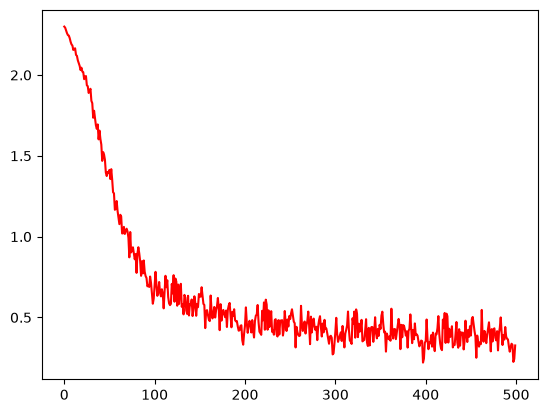

In [13]:
plt.plot(loss_list, 'r')

## 步驟7：評分(Score Model)

In [ ]:
# 建立 DataLoader
test_loader = DataLoader(test_ds, shuffle=False, batch_size=test_ds.targets.shape[0])

model.eval()
test_loss = 0
correct = 0
data: torch.Tensor
target: torch.Tensor
for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    output: torch.Tensor = model(data)

    # sum up batch loss
    test_loss += criterion.forward(output, target).item()

    # 預測
    pred = output.argmax(dim=1, keepdim=True)

    # 正確筆數
    correct += pred.eq(target.view_as(pred)).sum().item()

# 顯示測試結果
data_count = len(test_ds.data)
percentage = 100.0 * correct / data_count
print(f'平均損失: {test_loss:.4f}, 準確率: {correct}/{data_count} ({percentage:.0f}%)\n')

平均損失: 0.3265, 準確率: 9050/10000 (90%)



## 使用 torchmetrics

In [15]:
!pip install torchmetrics

In [16]:
torchmetrics.functional.accuracy(pred.reshape(-1), test_ds.targets.to(device), 'multiclass', num_classes=10)

tensor(0.9050, device='mps:0')

## 實際比對測試資料的前20筆

In [17]:
# 實際預測 20 筆資料
test_loader = DataLoader(test_ds, shuffle=False, batch_size=20)
data: torch.Tensor
target: torch.Tensor
data, target = next(iter(test_loader))
data = data.to(device)
pred: torch.Tensor = model(data)
output = pred.argmax(dim=1, keepdim=True)
predictions = output.cpu().numpy()

# 比對
print('實際值:', ' '.join(target.numpy().astype(str)))
print('預測值:', ' '.join(predictions.astype(str).reshape(-1)))

實際值: 7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4
預測值: 7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4


In [18]:
# 顯示第 9 筆的機率
i = 8
data: torch.Tensor = test_ds[i][0]
data = data.reshape(1, *data.shape).to(device)
# print(data.shape)
pred: torch.Tensor = model(data)
predictions = torch.softmax(pred, dim=1)
print(f'預測機率: {np.around(predictions.detach().cpu().numpy(), 2)}')
print(f'預測類別: {pred.argmax(dim=1).item()}')

預測機率: [[0.   0.   0.01 0.   0.03 0.   0.96 0.   0.   0.  ]]
預測類別: 6


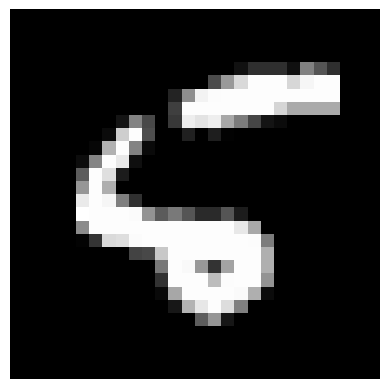

In [19]:
# 顯示第 9 筆圖像
X2: torch.Tensor = test_ds[i][0]
plt.imshow(X2.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

## 步驟8：評估，暫不進行

## 步驟9：模型佈署

In [20]:
# 模型存檔
torch.save(model, 'model.pt')

# 模型載入
model: nn.Sequential = torch.load('model.pt', weights_only=False)

In [21]:
# 權重存檔
torch.save(model.state_dict(), 'model.pth')

# 權重載入
model.load_state_dict(torch.load('model.pth'))

<All keys matched successfully>

In [22]:
# 顯示每一層的 state_dict 維度
print("每一層的 state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

每一層的 state_dict:
1.weight 	 torch.Size([256, 784])
1.bias 	 torch.Size([256])
3.weight 	 torch.Size([64, 256])
3.bias 	 torch.Size([64])
5.weight 	 torch.Size([10, 64])
5.bias 	 torch.Size([10])


## 步驟10：新資料預測

In [23]:
# 使用小畫家，繪製 0~9，實際測試看看
# 讀取影像並轉為單色
# image to a Torch tensor
transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=1), transforms.Resize([28, 28]), transforms.PILToTensor()]
)
for i in range(10):
    uploaded_file = f'./myDigits/{i}.png'
    image = Image.open(uploaded_file)
    X1 = cast(torch.Tensor, transform(image))
    X1 = torch.FloatTensor(255.0 - X1).to(device)
    pred: torch.Tensor = model(X1)
    print(f'actual/prediction: {i} {pred.argmax(dim=1).item()}')

actual/prediction: 0 0
actual/prediction: 1 1
actual/prediction: 2 2
actual/prediction: 3 0
actual/prediction: 4 9
actual/prediction: 5 5
actual/prediction: 6 6
actual/prediction: 7 3
actual/prediction: 8 8
actual/prediction: 9 8


## 其他：顯示模型彙總資訊(summary)、繪製圖形顯示模型結構

In [24]:
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=64, out_features=10, bias=True)
)


In [25]:
# 顯示模型的彙總資訊
for name, module in model.named_children():
    print(f'{name}: {module}')

0: Flatten(start_dim=1, end_dim=-1)
1: Linear(in_features=784, out_features=256, bias=True)
2: Dropout(p=0.2, inplace=False)
3: Linear(in_features=256, out_features=64, bias=True)
4: Dropout(p=0.2, inplace=False)
5: Linear(in_features=64, out_features=10, bias=True)


In [26]:
!pip install torchinfo

In [27]:
summary(model, (60000, 28, 28))  # input dimension size

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [60000, 10]               --
├─Flatten: 1-1                           [60000, 784]              --
├─Linear: 1-2                            [60000, 256]              200,960
├─Dropout: 1-3                           [60000, 256]              --
├─Linear: 1-4                            [60000, 64]               16,448
├─Dropout: 1-5                           [60000, 64]               --
├─Linear: 1-6                            [60000, 10]               650
Total params: 218,058
Trainable params: 218,058
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 13.08
Input size (MB): 188.16
Forward/backward pass size (MB): 158.40
Params size (MB): 0.87
Estimated Total Size (MB): 347.43

## PyTorch 無法繪製模型